## Practical case 1
Sofía Jimeno Lucía

In [1]:
## Libraries

import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from experiments import *

In [2]:
## Variables
path_img = './dataset/'
list_dir_dme = os.listdir(path_img + 'DME')
list_dir_normal = os.listdir(path_img + 'NORMAL')

In [3]:
# Geting data
im_path_list = []
target = []
y_real = []

for img_file in list_dir_dme:
    im_path_list += [path_img + 'DME/' + img_file]
    target += ["dme"]
    y_real += [1]
    
for img_file in list_dir_normal:
    im_path_list += [path_img + 'NORMAL/' + img_file]
    target += ["normal"]
    y_real += [0]

y_real = np.asarray(y_real)

# Spliting dataset train/test
idx_train, idx_test = train_test_split(range(0, len(im_path_list)), test_size = 0.3, random_state = 42)


F1 score mean 10 k-fold: 0.787
F1 score std 10 k-fold: 0.135
F1 score test: 0.971


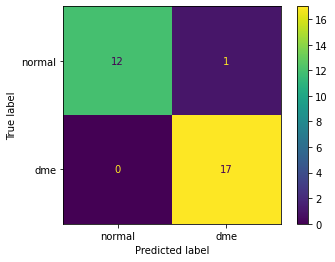

In [6]:
# Create experiment
experiment = Experiment(lbp_numPoints = 28, 
                         lbp_radius = 6, 
                         lbp_method = "uniform",
                         lbp_eps = 1e-7,
                         glcm_list_distances = [1], 
                         glcm_list_angles = [0], 
                         glcm_gray_level = 256,
                         gf_gamma = 0.5, 
                         gf_sigma = 0.56, 
                         gf_phi = 0, 
                         gf_theta_list = [0, np.pi, np.pi/2, np.pi/4, 3*np.pi/4], 
                         gf_lamda_list = [2*np.pi/1, 2*np.pi/2, 2*np.pi/3, 2*np.pi/4, 2*np.pi/5],
                         pca_n_components = 20,
                         resize_dim = (1024, 512),
                         rfe_algorithm = RandomForestClassifier(n_estimators = 200, n_jobs = -1),
                         rfe_n_features = 30,
                         algorithm = RandomForestClassifier(n_estimators = 300))

# Run experiment
sel_features, cv_mean, cv_std, score, disp = experiment.run(np.asarray(im_path_list),
                                       y_real,
                                       np.asarray(idx_train), 
                                       idx_test)
print('F1 score mean 10 k-fold: %.3f' % cv_mean)
print('F1 score std 10 k-fold: %.3f' % cv_std)
print('F1 score test: %.3f' % score)
disp.plot()